In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel(r"D:\Sales data from apr'16 -jan'26.xlsx",sheet_name="APR'16-JAN'26")

In [4]:
df.head()

,Date,Total_QTY
0,2016-04-01,295304.80
1,2016-05-01,389404.85
2,2016-06-01,454429.85
3,2016-07-01,302825.05
4,2016-08-01,302694.25


In [5]:
df.value_counts()

Date        Total_QTY
2016-04-01  295304.80    1
2016-05-01  389404.85    1
2016-06-01  454429.85    1
2016-07-01  302825.05    1
2016-08-01  302694.25    1
                        ..
2025-09-01  398459.60    1
2025-10-01  371623.74    1
2025-11-01  385197.75    1
2025-12-01  452421.20    1
2026-01-01  474775.85    1
Name: count, Length: 118, dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Ensure monthly frequency
df = df.asfreq('MS')   # MS = Month Start

In [7]:
df.head()

,Total_QTY
Date,
2016-04-01,295304.80
2016-05-01,389404.85
2016-06-01,454429.85
2016-07-01,302825.05
2016-08-01,302694.25


In [8]:
df.isnull().sum()

Total_QTY    0
dtype: int64

In [9]:
df['covid_dummy'] = 0
df.loc['2020-04-01':'2021-03-01', 'covid_dummy'] = 1

In [10]:
df.head()

,Total_QTY,covid_dummy
Date,,
2016-04-01,295304.80,0
2016-05-01,389404.85,0
2016-06-01,454429.85,0
2016-07-01,302825.05,0
2016-08-01,302694.25,0


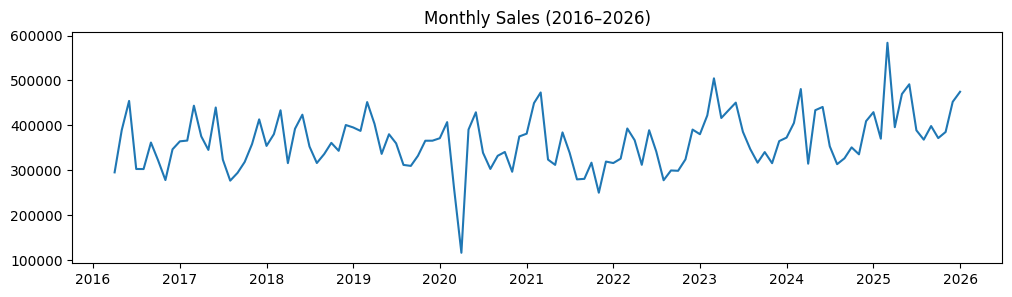

In [11]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(df['Total_QTY'])
plt.title("Monthly Sales (2016–2026)")
plt.show()

#Strong long-term upward trend
#Strong annual seasonality (period = 12)

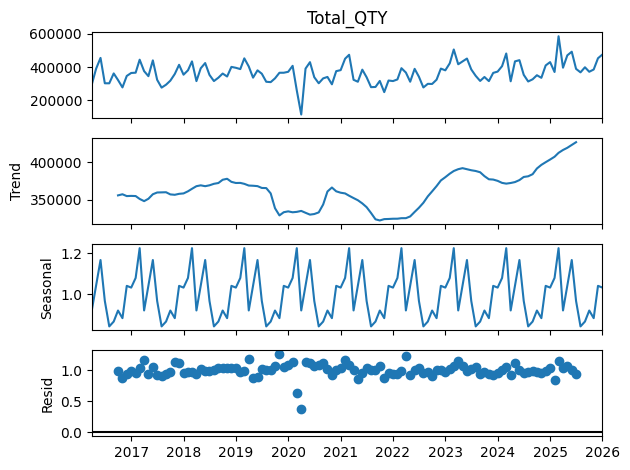

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Total_QTY'], model='multiplicative', period=12)
result.plot()
plt.show()

# Multiplicative will be good to proceed with.

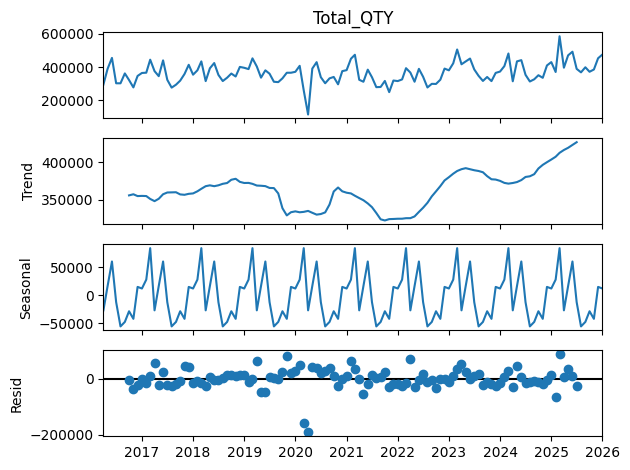

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Total_QTY'], model='additive', period=12)
result.plot()
plt.show()

In [15]:
#| Component        | Conclusion                 |
#| ---------------- | -------------------------- |
#| Trend            | Strong upward              |
#| Seasonality      | Strong, stable (12 months) |
#| Structural Break | Yes (2020)                 |
#| Residual         | Mostly white noise         |
#| Stationary?      | ❌ No                       |


ADF (Augmented Dickey-Fuller) tests:

H₀ (Null Hypothesis):

Series is non-stationary

H₁ (Alternative):

Series is stationary

So:

p-value > 0.05 → Non-stationary ❌

p-value < 0.05 → Stationary ✅

In [16]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Total_QTY'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

ADF Statistic: -0.5111500058645995
p-value: 0.8898222200781611
Critical Values: {'1%': np.float64(-3.4936021509366793), '5%': np.float64(-2.8892174239808703), '10%': np.float64(-2.58153320754717)}


In [18]:
df['diff1'] = df['Total_QTY'].diff()

result_diff1 = adfuller(df['diff1'].dropna())

print("ADF Statistic:", result_diff1[0])
print("p-value:", result_diff1[1])

ADF Statistic: -3.7304347323704996
p-value: 0.0037048677807254


In [21]:
df['seasonal_diff'] = df['Total_QTY'].diff(12)
adfuller(df['seasonal_diff'].dropna())

(np.float64(-3.788645261660237),
 np.float64(0.003025648888794865),
 12,
 93,
 {'1%': np.float64(-3.502704609582561),
  '5%': np.float64(-2.8931578098779522),
  '10%': np.float64(-2.583636712914788)},
 np.float64(2268.270735226137))

In [22]:
df['combined_diff'] = df['Total_QTY'].diff().diff(12)
adfuller(df['combined_diff'].dropna())

(np.float64(-4.409877353541805),
 np.float64(0.00028511030189955954),
 13,
 91,
 {'1%': np.float64(-3.50434289821397),
  '5%': np.float64(-2.8938659630479413),
  '10%': np.float64(-2.5840147047458037)},
 np.float64(2254.018012612826))

In [26]:
train = df.iloc[:-12]
test = df.iloc[-12:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 106
Test size: 12


In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train['Total_QTY'],
                order=(0,1,1),
                seasonal_order=(0,1,1,12),
                exog=train[['covid_dummy']])

results = model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          Total_QTY   No. Observations:                  106
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1154.432
Date:                            Mon, 23 Feb 2026   AIC                           2316.864
Time:                                    16:55:30   BIC                           2326.995
Sample:                                04-01-2016   HQIC                          2320.955
                                     - 01-01-2025                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
covid_dummy  6547.1667   2.94e+04      0.222      0.824   -5.12e+04    6.43e+04
ma.L1          -0.2650      0.09

In [28]:

forecast = results.forecast(steps=12,
                            exog=test[['covid_dummy']])

In [30]:
forecast

2025-02-01    453673.181822
2025-03-01    505754.902549
2025-04-01    401684.997681
2025-05-01    453860.687266
2025-06-01    487979.335630
2025-07-01    418701.462054
2025-08-01    374786.777486
2025-09-01    379807.805495
2025-10-01    398705.610824
2025-11-01    383401.812061
2025-12-01    444847.355073
2026-01-01    450575.075924
Freq: MS, Name: predicted_mean, dtype: float64

In [31]:
mape = np.mean(np.abs((test['Total_QTY'] - forecast) / test['Total_QTY']))
print("MAPE:", mape)

MAPE: 0.058408818259329094


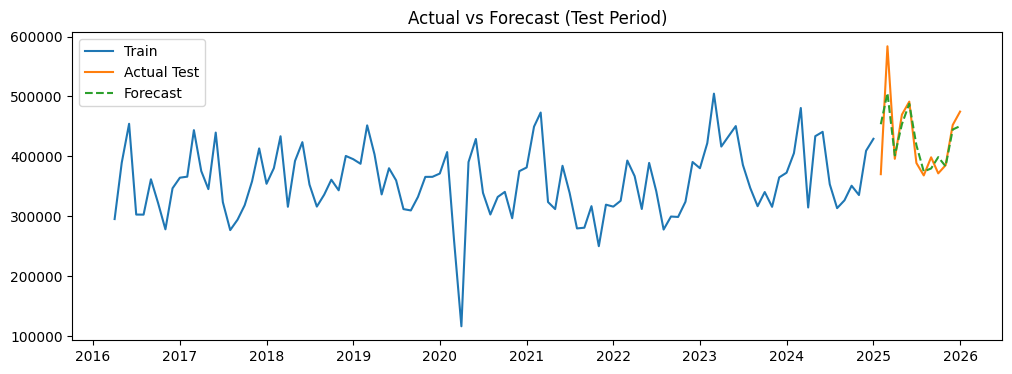

In [32]:
plt.figure(figsize=(12,4))

plt.plot(train.index, train['Total_QTY'], label='Train')
plt.plot(test.index, test['Total_QTY'], label='Actual Test')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')

plt.legend()
plt.title('Actual vs Forecast (Test Period)')
plt.show()

#model validation
# 1️⃣ Residual Diagnostics (Most Important)
A good time-series model must leave:

Residuals = White Noise

That means:

No autocorrelation

No pattern

Mean ≈ 0

Constant variance (ideally)


# 2️⃣ Overfitting Check

# 3️⃣ Stability of Forecast

# 4️⃣ Compare With Naive Model(Benchmark Test)


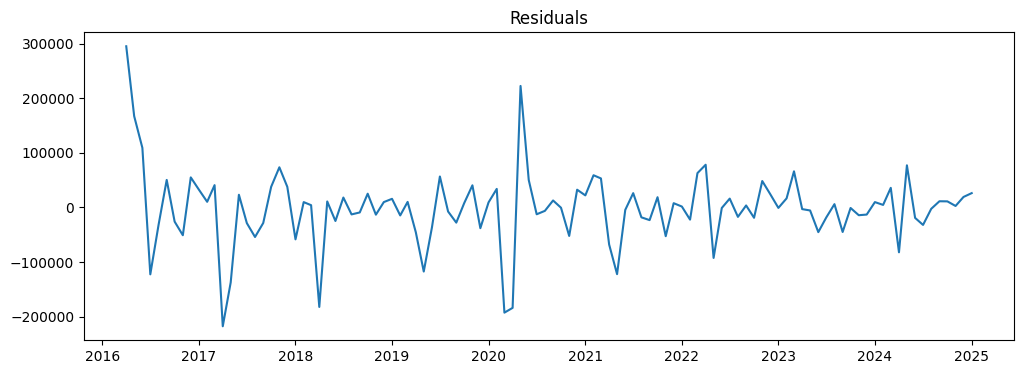

In [33]:
#🔹 Check Residual Plot

residuals = results.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

#You should NOT see:

#Trend

#Seasonality

#Pattern

#If pattern exists → model missing structure.

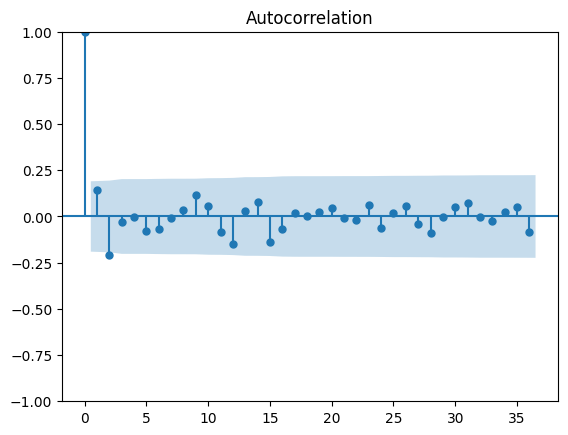

In [34]:
#🔹 Check Residual ACF

plot_acf(residuals.dropna(), lags=36)
plt.show()


#If spikes outside confidence band → model incomplete.

#If most spikes inside band → good.

In [35]:
#🔹 Ljung-Box Test(from model)
#Since p > 0.05:

#✅ Residuals are not autocorrelated
#This is strong evidence of good fit.

In [36]:
#✅ 2️⃣ Overfitting Check
#✅ 3️⃣ Stability of Forecast

In [37]:
#Seasonal Naive Forecast
#Meaning:
#Next year same month = last year same month.
#If your SARIMA beats naive model significantly → real improvement

In [38]:
# Seasonal Naive Forecast (lag 12)
naive_forecast = train['Total_QTY'].iloc[-12:].values

# Align with test index
naive_forecast = pd.Series(naive_forecast, index=test.index) 

In [39]:
naive_forecast

Date
2025-02-01    405309.55
2025-03-01    480804.10
2025-04-01    314631.15
2025-05-01    433726.98
2025-06-01    441003.95
2025-07-01    353430.85
2025-08-01    313524.20
2025-09-01    326615.30
2025-10-01    350967.12
2025-11-01    335447.08
2025-12-01    409358.03
2026-01-01    429350.90
Freq: MS, dtype: float64

In [40]:
#Calculate Errors for Naive Model

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(test['Total_QTY'], naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test['Total_QTY'], naive_forecast))
mape_naive = np.mean(np.abs((test['Total_QTY'] - naive_forecast) / test['Total_QTY'])) * 100

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)
print("Naive MAPE:", mape_naive)

Naive MAE: 52229.435000000085
Naive RMSE: 56663.60580395023
Naive MAPE: 12.09530208913505


📊 What This Means

Your model reduced error by:

12.09
−
5.84
12.09
≈
52
%
12.09
12.09−5.84
	​

≈52%

👉 More than 50% improvement over baseline.

That is NOT small.
That is significant predictive gain.

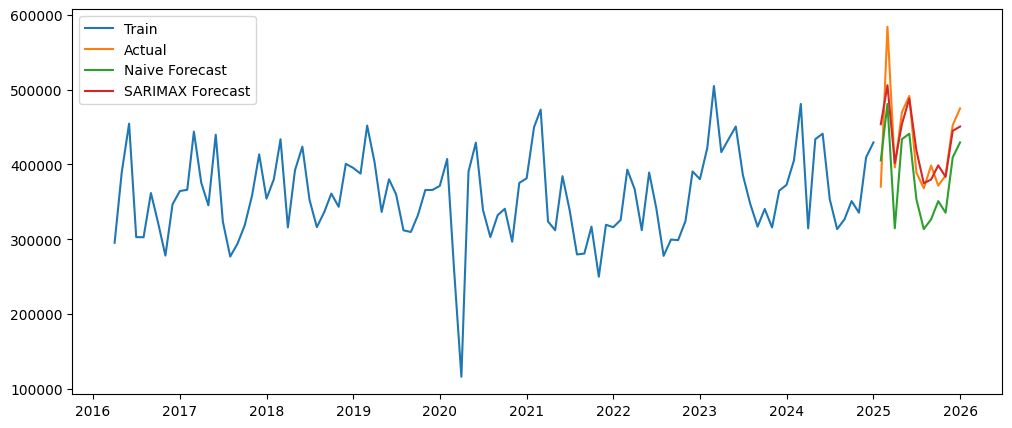

In [41]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Total_QTY'], label='Train')
plt.plot(test.index, test['Total_QTY'], label='Actual')
plt.plot(test.index, naive_forecast, label='Naive Forecast')
plt.plot(test.index, forecast, label='SARIMAX Forecast')
plt.legend()
plt.show()

In [42]:
#✅ STEP 1 — Remove COVID Dummy

model_final = SARIMAX(
    train['Total_QTY'],
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

results_final = model_final.fit()
print(results_final.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          Total_QTY   No. Observations:                  106
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1154.546
Date:                            Mon, 23 Feb 2026   AIC                           2315.092
Time:                                    16:55:32   BIC                           2322.690
Sample:                                04-01-2016   HQIC                          2318.160
                                     - 01-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2611      0.081     -3.231      0.001      -0.419      -0.103
ma.S.L12      -0.6770      0.105   

In [43]:
print("Old AIC:", results.aic)        # with dummy
print("New AIC:", results_final.aic)  # without dummy

Old AIC: 2316.864243352002
New AIC: 2315.091879494666


In [44]:
forecast_final = results_final.forecast(steps=len(test))

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_final = mean_absolute_error(test['Total_QTY'], forecast_final)
rmse_final = np.sqrt(mean_squared_error(test['Total_QTY'], forecast_final))
mape_final = np.mean(np.abs((test['Total_QTY'] - forecast_final) / test['Total_QTY'])) * 100

print("Final MAE:", mae_final)
print("Final RMSE:", rmse_final)
print("Final MAPE:", mape_final)

Final MAE: 25204.57940577296
Final RMSE: 36531.57295647019
Final MAPE: 5.84432611842931


In [45]:
model_locked = SARIMAX(
    df['Total_QTY'],
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

results_locked = model_locked.fit()

In [46]:
future_forecast = results_locked.get_forecast(steps=12)

forecast_values = future_forecast.predicted_mean
confidence_intervals = future_forecast.conf_int()

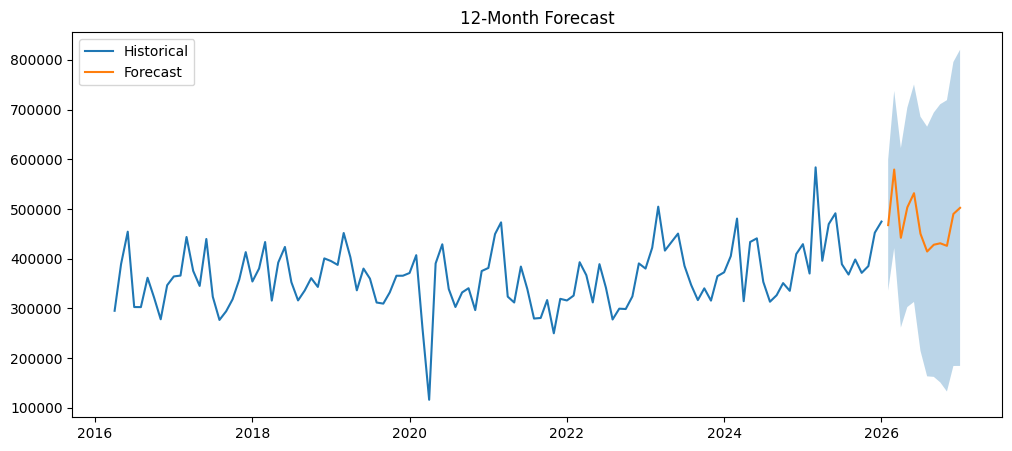

In [47]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Total_QTY'], label='Historical')
plt.plot(forecast_values.index, forecast_values, label='Forecast')

plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title("12-Month Forecast")
plt.show()

In [48]:
print(forecast_values)

2026-02-01    467650.975311
2026-03-01    579450.639249
2026-04-01    442159.766278
2026-05-01    503349.662980
2026-06-01    531872.855629
2026-07-01    450352.168771
2026-08-01    414564.168030
2026-09-01    428192.240671
2026-10-01    431080.999340
2026-11-01    425960.128988
2026-12-01    490070.269151
2027-01-01    502400.211868
Freq: MS, Name: predicted_mean, dtype: float64


In [49]:
#✅ MODEL 1 — Holt-Winters (Triple Exponential Smoothing)


from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train['Total_QTY'],
    trend='add',
    seasonal='mul',   # try 'add' also later
    seasonal_periods=12
)

hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(steps=len(test))

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_hw = mean_absolute_error(test['Total_QTY'], hw_forecast)
rmse_hw = np.sqrt(mean_squared_error(test['Total_QTY'], hw_forecast))
mape_hw = np.mean(np.abs((test['Total_QTY'] - hw_forecast) / test['Total_QTY'])) * 100

print("Holt-Winters MAPE:", mape_hw)

Holt-Winters MAPE: 11.956420866288441


In [51]:
##✅ MODEL 2 — Holt’s Linear Trend (No Seasonality)
hw_linear = ExponentialSmoothing(
    train['Total_QTY'],
    trend='add',
    seasonal=None
)

fit_linear = hw_linear.fit()
forecast_linear = fit_linear.forecast(len(test))

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

linear_hw = mean_absolute_error(test['Total_QTY'], forecast_linear)
linear_hw = np.sqrt(mean_squared_error(test['Total_QTY'], forecast_linear))
linear_hw = np.mean(np.abs((test['Total_QTY'] - forecast_linear) / test['Total_QTY'])) * 100

print("Holt-Winters-linear MAPE:", linear_hw)

Holt-Winters-linear MAPE: 13.643340456461669


In [53]:
#✅ MODEL 3 — Simple Exponential Smoothing (Baseline Smooth)
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(train['Total_QTY'])
ses_fit = ses_model.fit()
ses_forecast = ses_fit.forecast(len(test))

In [54]:
ses_hw = mean_absolute_error(test['Total_QTY'], ses_forecast)
ses_hw = np.sqrt(mean_squared_error(test['Total_QTY'], ses_forecast))
ses_hw = np.mean(np.abs((test['Total_QTY'] - ses_forecast) / test['Total_QTY'])) * 100

print("Holt-Winters simple MAPE:", ses_hw)

Holt-Winters simple MAPE: 11.267295969584497


In [55]:
print("SARIMA MAPE:", 5.84)
print("Naive MAPE:", 12.09)
print("Holt-Winters MAPE:", mape_hw)
print("Holt Linear MAPE:", linear_hw)
print("SES MAPE:", ses_hw)

SARIMA MAPE: 5.84
Naive MAPE: 12.09
Holt-Winters MAPE: 11.956420866288441
Holt Linear MAPE: 13.643340456461669
SES MAPE: 11.267295969584497


In [56]:
###### try with other parameters too

hw_model1 = ExponentialSmoothing(
    train['Total_QTY'],
    trend='add',
    seasonal='add',   # try 'add' also later
    seasonal_periods=12
)

hw_fit1 = hw_model1.fit()

hw_forecast1 = hw_fit1.forecast(steps=len(test))

mape_hw1 = np.mean(np.abs((test['Total_QTY'] - hw_forecast1) / test['Total_QTY'])) * 100

print("Holt-Winters MAPE:", mape_hw1)

Holt-Winters MAPE: 10.982472308373469


In [57]:
hw_model2 = ExponentialSmoothing(
    train['Total_QTY'],
    trend='mul',
    seasonal='add',   # try 'add' also later
    seasonal_periods=12
)

hw_fit2 = hw_model2.fit()

hw_forecast2 = hw_fit2.forecast(steps=len(test))

mape_hw2 = np.mean(np.abs((test['Total_QTY'] - hw_forecast2) / test['Total_QTY'])) * 100

print("Holt-Winters MAPE:", mape_hw2)

Holt-Winters MAPE: 11.785732948022448


In [58]:
hw_model3 = ExponentialSmoothing(
    train['Total_QTY'],
    trend='mul',
    seasonal='mul',   # try 'add' also later
    seasonal_periods=12
)

hw_fit3 = hw_model3.fit()

hw_forecast3 = hw_fit3.forecast(steps=len(test))

mape_hw3 = np.mean(np.abs((test['Total_QTY'] - hw_forecast3) / test['Total_QTY'])) * 100

print("Holt-Winters MAPE:", mape_hw3)

Holt-Winters MAPE: 11.354263024985233


In [59]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [60]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train['Total_QTY'],
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.10 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2628.031, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2612.111, Time=1.10 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2603.190, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3016.559, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=2607.687, Time=0.05 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=2605.074, Time=0.63 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=2599.178, Time=0.28 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=2601.115, Time=0.54 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=2615.136, Time=0.15 sec
 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=2605.333, Time=0.27 sec
 ARIMA(0,0,2)(0,0,2)[12] intercept   : AIC=2597.003, Time=0.20 sec
 ARIMA(0,0,2)(0,0,1)[12] intercept   : AIC=2601.532, Time=0.10 sec
 ARIMA(0,0,2)(1,0,2)[12] intercept   : AIC=2598.973, Time=0.51 sec
 ARIMA(0,0,2)(1,0,1)[12]

In [61]:
##-------------------------Step 1 — Rolling One-Step Ahead Forecast

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

rolling_errors = []

# start after enough data (at least 2 years)
start_point = 60  

for i in range(start_point, len(df)-1):
    
    train_roll = df['Total_QTY'][:i]
    test_roll = df['Total_QTY'][i:i+1]

    model_roll = SARIMAX(
        train_roll,
        order=(0,1,1),
        seasonal_order=(0,1,1,12)
    )
    
    results_roll = model_roll.fit(disp=False)
    forecast_roll = results_roll.forecast(steps=1)

    error = mean_absolute_percentage_error(test_roll, forecast_roll)
    rolling_errors.append(error)

rolling_mape = np.mean(rolling_errors) * 100
print("Rolling MAPE:", rolling_mape)

D:\ANACONDA PYTHON\envs\New_Enviroment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
D:\ANACONDA PYTHON\envs\New_Enviroment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
D:\ANACONDA PYTHON\envs\New_Enviroment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


Rolling MAPE: 8.542391125728468


In [62]:
## model_tuned SARIMA

model_tuned = SARIMAX(
    train['Total_QTY'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results_tuned = model_tuned.fit()

forecast_tuned = results_tuned.forecast(len(test))

mape_tuned = np.mean(np.abs((test['Total_QTY'] - forecast_tuned) / test['Total_QTY'])) * 100
print("Tuned SARIMA MAPE:", mape_tuned)

Tuned SARIMA MAPE: 6.39620055477602


In [63]:
##A2 — Log Transformation (Very Powerful)

train_log = np.log(train['Total_QTY'])
test_log = np.log(test['Total_QTY'])

model_log = SARIMAX(
    train_log,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

results_log = model_log.fit()
forecast_log = results_log.forecast(len(test))

# Convert back
forecast_original = np.exp(forecast_log)

mape_log = np.mean(np.abs((test['Total_QTY'] - forecast_original) / test['Total_QTY'])) * 100
print("Log SARIMA MAPE:", mape_log)

Log SARIMA MAPE: 11.394996129325099


In [64]:
#A3 — Box-Cox Transformation

from scipy.stats import boxcox

train_boxcox, lam = boxcox(train['Total_QTY'])

model_box = SARIMAX(
    train_boxcox,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

results_box = model_box.fit()
forecast_box = results_box.forecast(len(test))

# Inverse transform
forecast_original = np.power(forecast_box * lam + 1, 1/lam)

mape_box = np.mean(np.abs((test['Total_QTY'] - forecast_original) / test['Total_QTY'])) * 100
print("BoxCox SARIMA MAPE:", mape_box)

BoxCox SARIMA MAPE: 6.21023991267366


In [65]:
####Prophet Models
from prophet import Prophet

df_prophet = pd.DataFrame({
    'ds': df.index,
    'y': df['Total_QTY']
})

Importing plotly failed. Interactive plots will not work.


In [66]:
df_prophet

,ds,y
Date,,
2016-04-01,2016-04-01,295304.80
2016-05-01,2016-05-01,389404.85
2016-06-01,2016-06-01,454429.85
2016-07-01,2016-07-01,302825.05
2016-08-01,2016-08-01,302694.25
...,...,...
2025-09-01,2025-09-01,398459.60
2025-10-01,2025-10-01,371623.74
2025-11-01,2025-11-01,385197.75


In [67]:
#pip install prophet

In [68]:
from prophet import Prophet

# Train-test split (same split as SARIMA)
train_prophet = df_prophet.iloc[:len(train)]
test_prophet = df_prophet.iloc[len(train):]

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet.fit(train_prophet)

future = model_prophet.make_future_dataframe(
    periods=len(test),
    freq='MS'   # Month Start (important!)
)

forecast_prophet = model_prophet.predict(future)


16:55:57 - cmdstanpy - INFO - Chain [1] start processing
16:55:57 - cmdstanpy - INFO - Chain [1] done processing


In [69]:
forecast_values = forecast_prophet['yhat'][-len(test):].values

mape_prophet = np.mean(
    np.abs((test['Total_QTY'].values - forecast_values)
           / test['Total_QTY'].values)
) * 100

print("Prophet MAPE:", mape_prophet)

Prophet MAPE: 12.577911361524476
